In [2]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import pandas as pd# 0. Experiment selection
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

# 0. Experiment selection

In [3]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251112_small_smallddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

Testing experiment: da_numu_251112_small_smallddnoreg_aug_newlr
Device: cuda:1


In [4]:
# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 64
- Seed: 42
- Max hits: 500


# 1. Load trained models: basic + domain discriminator

In [5]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()

# Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Domain discriminator parameters: {sum(p.numel() for p in domain_discriminator.parameters()):,}")

Loading checkpoint from: ../experiments/numu/da_numu_251112_small_smallddnoreg_aug_newlr/best_da_model.pth


/tmp/ipykernel_607810/459895799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Models loaded successfully:
- Epoch: 34
- Best metric: 0.9392259688555985
- Base model parameters: 53,185
- Domain discriminator parameters: 2,113


# 2. Load data to test on

## 2.1 Source (MC) domain

In [6]:
# Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']

# Use validation portion of source data for testing (events model hasn't seen)
test_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
print(f"Test dataset created with {len(test_dataset)} events")
print(f"Particle distribution:")
for particle in source_config['particle_types']:
    count = sum(1 for i in range(len(test_dataset)) if test_dataset.event_ids[i].split(":")[0] == particle)
    print(f"  {particle}: {count:,} events")
    
    
# Create test dataloader
test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {test_dataloader.batch_size}")
print(f"- Number of batches: {len(test_dataloader)}")
print(f"- Total events: {len(test_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

Test dataset created with 1000000 events
Particle distribution:
  muatm_2020: 500,000 events
  nue2_2020: 250,000 events
  nuatm_2020: 250,000 events
Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]


## 2.2 Target (EXP) domain

In [7]:
# Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)

target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


# 3. Make predctions and extract meta-info

## 3.1 Source (MC) domain

In [8]:
from torch.nn.utils.rnn import pack_padded_sequence, unpack_sequence

# Make predictions on test data
print("Making predictions...")

mc_raw_data = []
all_predictions = []
all_probabilities = []
all_labels = []
all_features = []
all_magic_numbers = []
all_channels_ids = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        all_features.append(feature_repr.cpu())
        all_predictions.append(predictions_batch.cpu())
        all_probabilities.append(probabilities_batch.cpu())
        all_labels.append(batch['labels'].cpu())
        all_magic_numbers.append(batch['magic_numbers'])
        all_channels_ids.append(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        mc_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        
# Concatenate all results
features = torch.cat(all_features, dim=0).numpy()
predictions = torch.cat(all_predictions, dim=0).numpy().flatten()
probabilities = torch.cat(all_probabilities, dim=0).numpy().flatten()
labels = torch.cat(all_labels, dim=0).numpy().flatten()
magic_numbers = []
for values in all_magic_numbers:
    magic_numbers += values
channels_ids = []
for values in all_channels_ids:
    channels_ids += values

Making predictions...


  0%|          | 0/3907 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 3907/3907 [01:36<00:00, 40.41it/s]


Some stats

In [9]:
# MC Truth
signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in magic_numbers])
signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(magic_numbers, channels_ids)])

In [42]:
# For Q filters
q_mean, q_std = normalization_config['means'][0], normalization_config['stds'][0]
mc_q_mean = np.asarray([
    (event[:,0]*q_std+q_mean).mean() for event in mc_raw_data
    ])
mc_qgt10_num = np.asarray([
    np.sum((event[:,0]*q_std+q_mean)>10) for event in mc_raw_data
    ], dtype=int
    )
mc_qgt20_num = np.asarray([
    np.sum((event[:,0]*q_std+q_mean)>20) for event in mc_raw_data
    ], dtype=int
    )
print(f"Number of MC events with 2 hits > 10 eV: {(mc_qgt10_num>=2).sum()} of {len(mc_qgt10_num)}, {100*(mc_qgt10_num>=2).sum()/len(mc_qgt10_num):.3f}%")

Number of MC events with 2 hits > 10 eV: 220276 of 1000000, 22.028%


In [38]:
# For coordinates filters
t_mean, t_std = normalization_config['means'][1], normalization_config['stds'][1]
x_mean, x_std = normalization_config['means'][2], normalization_config['stds'][2]
y_mean, y_std = normalization_config['means'][3], normalization_config['stds'][3]
z_mean, z_std = normalization_config['means'][4], normalization_config['stds'][4]
q_mean, q_std = normalization_config['means'][0], normalization_config['stds'][0]
mc_z_mean = np.asarray([
    (event[:,4]*z_std+z_mean).mean() for event in mc_raw_data
    ])
mc_x_mean = np.asarray([
    (event[:,2]*x_std+x_mean).mean() for event in mc_raw_data
    ])
mc_y_mean = np.asarray([
    (event[:,3]*y_std+y_mean).mean() for event in mc_raw_data
    ])
mc_t_mean = np.asarray([
    (event[:,1]*t_std+t_mean).mean() for event in mc_raw_data
    ])
mc_z_weight_q = np.asarray([
    np.sum((event[:,4]*z_std+z_mean)*(event[:,0]*q_std+q_mean))/(event[:,0]*q_std+q_mean).sum() for event in mc_raw_data
    ])
print(f"Number of MC events with weighted_Z<220: {(mc_z_weight_q<220).sum()} of {len(mc_z_weight_q)}, {100*(mc_z_weight_q<220).sum()/len(mc_z_weight_q):.3f}%")

Number of MC events with weighted_Z<220: 997141 of 1000000, 99.714%


## 3.2 Target (EXP) domain

In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence, unpack_sequence

# Make p preds for EXP data
print("Making predictions...")

exp_numu_predictions = []
exp_numu_probabilities = []
exp_numu_features = []
exp_raw_data = []

with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        # # TO REMOVE!!! SHIFTING Z FOR EXP
        # shifted_features = batch['features']
        # shifted_features[:,:,4] = shifted_features[:,:,4] + (28-z_mean)/z_std
        # batch['features'] = shifted_features
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_numu_features.append(feature_repr.cpu())
        exp_numu_predictions.append(predictions_batch.cpu())
        exp_numu_probabilities.append(probabilities_batch.cpu())
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        exp_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])

# Concatenate all results
exp_features = torch.cat(exp_numu_features, dim=0).numpy()
exp_predictions = torch.cat(exp_numu_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_numu_probabilities, dim=0).numpy().flatten()

print(f"Predictions complete:")
print(f"- Features shape: {exp_features.shape}")
print(f"- Predictions shape: {exp_predictions.shape}")
print(f"- Neutrino prediction rate: {np.mean(exp_predictions):.3f}")

Making predictions...


100%|██████████| 1368/1368 [00:33<00:00, 40.46it/s]

Predictions complete:
- Features shape: (349976, 64)
- Predictions shape: (349976,)
- Neutrino prediction rate: 0.168


In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence, unpack_sequence

# Source features (limited sample)
source_features_mu = torch.tensor(features[~labels], device=DEVICE)

# Target features
target_features = []
target_raw_data = []
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        # # TO REMOVE!!! SHIFTING Z FOR EXP
        # shifted_features = batch['features']
        # shifted_features[:,:,4] = shifted_features[:,:,4] + (28-z_mean)/z_std
        # batch['features'] = shifted_features
        # Predict features
        feature_repr = model.get_feature_representation(batch)
        target_features.append(feature_repr)
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        target_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])

# Combine and test domain discrimination
target_features = torch.cat(target_features, dim=0)

all_domain_features = torch.cat([source_features_mu, target_features], dim=0)#.to(DEVICE)
domain_labels = torch.cat([
    torch.zeros(source_features_mu.shape[0]),  # 0 = source
    torch.ones(target_features.shape[0])    # 1 = target
], dim=0)

# Get domain predictions
with torch.no_grad():
    domain_logits = domain_discriminator(all_domain_features)
    domain_probs = torch.sigmoid(domain_logits).cpu().numpy().flatten()
    domain_preds = (domain_probs > 0.5).astype(float)

domain_accuracy = accuracy_score(domain_labels.numpy(), domain_preds)
domain_auc = roc_auc_score(domain_labels.numpy(), domain_probs)
print(f"Domain discrimination accuracy: {domain_accuracy:.4f}")
print(f"Domain discrimination AUC: {domain_auc:.4f}")
print(f"Note: Lower accuracy indicates better domain adaptation")
print(f"Source samples: {source_features_mu.shape[0]:,}")
print(f"Target samples: {target_features.shape[0]:,}")

100%|██████████| 1368/1368 [00:31<00:00, 43.43it/s]


Domain discrimination accuracy: 0.5870
Domain discrimination AUC: 0.6044
Note: Lower accuracy indicates better domain adaptation
Source samples: 500,000
Target samples: 349,976


Some stats

In [43]:
# For Q filters
q_mean, q_std = normalization_config['means'][0], normalization_config['stds'][0]
exp_q_mean = np.asarray([
    (event[:,0]*q_std+q_mean).mean() for event in exp_raw_data
    ])
exp_qgt10_num = np.asarray([
    np.sum((event[:,0]*q_std+q_mean)>10) for event in exp_raw_data
    ], dtype=int
    )
exp_qgt20_num = np.asarray([
    np.sum((event[:,0]*q_std+q_mean)>20) for event in exp_raw_data
    ], dtype=int
    )
print(f"Number of MC events with 2 hits > 10 eV: \
{(exp_qgt10_num>=2).sum()} of {len(exp_qgt10_num)}, {100*(exp_qgt10_num>=2).sum()/len(exp_qgt10_num):.3f}%"
)

Number of MC events with 2 hits > 10 eV: 55571 of 349976, 15.879%


In [70]:
# For coordinates filters
t_mean, t_std = normalization_config['means'][1], normalization_config['stds'][1]
x_mean, x_std = normalization_config['means'][2], normalization_config['stds'][2]
y_mean, y_std = normalization_config['means'][3], normalization_config['stds'][3]
z_mean, z_std = normalization_config['means'][4], normalization_config['stds'][4]
q_mean, q_std = normalization_config['means'][0], normalization_config['stds'][0]
exp_z_mean = np.asarray([
    (event[:,4]*z_std+z_mean).mean() for event in exp_raw_data
    ])
exp_x_mean = np.asarray([
    (event[:,2]*x_std+x_mean).mean() for event in exp_raw_data
    ])
exp_y_mean = np.asarray([
    (event[:,3]*y_std+y_mean).mean() for event in exp_raw_data
    ])
exp_t_mean = np.asarray([
    (event[:,1]*t_std+t_mean).mean() for event in exp_raw_data
    ])
exp_z_weight_q = np.asarray([
    np.sum((event[:,4]*z_std+z_mean)*(event[:,0]*q_std+q_mean))/(event[:,0]*q_std+q_mean).sum() for event in exp_raw_data
    ])
print(f"Number of MC events with weighted_Z<220: {(exp_z_weight_q<220).sum()} of {len(exp_z_weight_q)}, {100*(exp_z_weight_q<220).sum()/len(exp_z_weight_q):.3f}%")

Number of MC events with weighted_Z<220: 349443 of 349976, 99.848%


# Plots

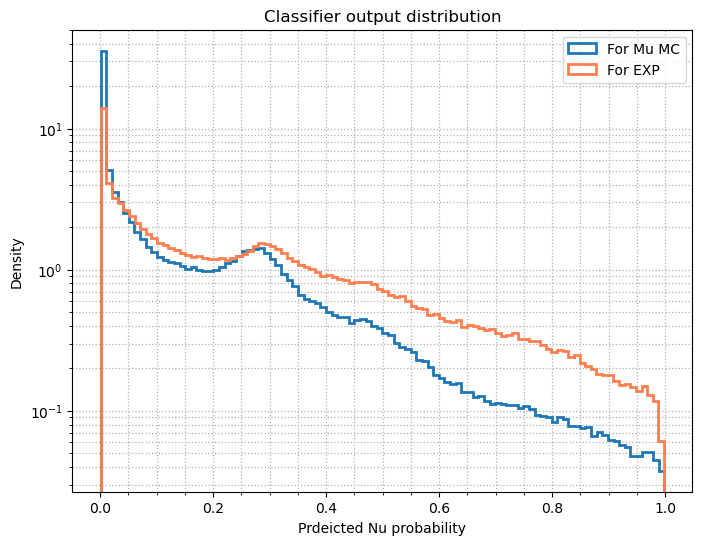

In [77]:
mc_mask = np.ones(len(probabilities), dtype=bool) #& (mc_qgt10_num>=2) & (mc_qgt20_num>=1)
labels_masked, probabilities_masked = labels[mc_mask], probabilities[mc_mask]

exp_mask = np.ones(len(exp_probabilities), dtype=bool) #& (exp_qgt10_num>=2) & (exp_qgt20_num>=1)
exp_probas_masked = exp_probabilities[exp_mask]

plt.figure(figsize=(8,6))
plt.hist(probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Mu MC')
plt.hist(exp_probas_masked, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label='For EXP')
plt.title("Classifier output distribution")
plt.legend()
plt.grid(which='both', ls=':', lw=0.9)

plt.xlabel("Prdeicted Nu probability")
plt.ylabel("Density")
plt.minorticks_on()

p_distr_fig = plt.gcf()
plt.show()
plt.close()

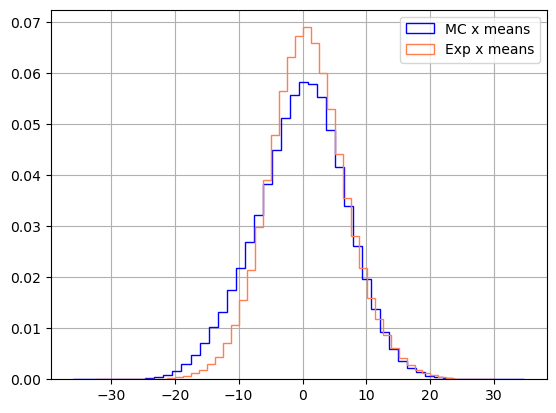

In [72]:
kwargs = dict(histtype='step', density=True)
plt.hist(mc_x_mean[~labels], bins=50, **kwargs, label='MC x means', ls='-', color='b')
plt.hist(exp_x_mean, bins=50, **kwargs, label='Exp x means', ls='-', color='coral')
plt.grid()
plt.legend()
plt.show()

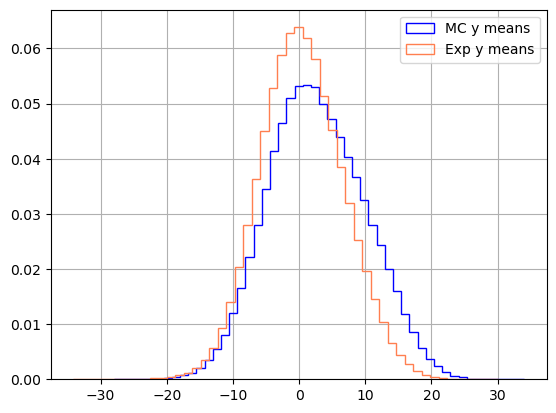

In [73]:
kwargs = dict(histtype='step', density=True)
plt.hist(mc_y_mean[~labels], bins=50, **kwargs, label='MC y means', ls='-', color='b')
plt.hist(exp_y_mean, bins=50, **kwargs, label='Exp y means', ls='-', color='coral')
plt.grid()
plt.legend()
plt.show()

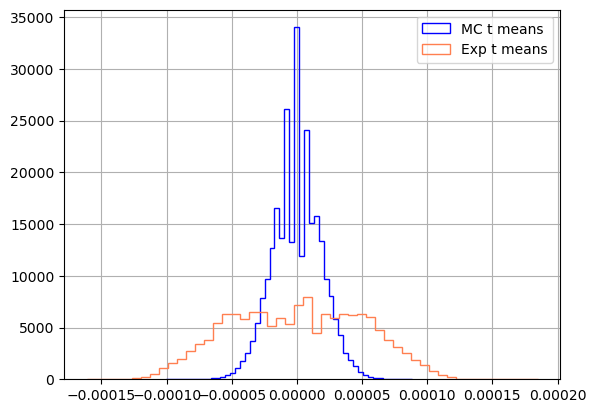

In [74]:
kwargs = dict(histtype='step', density=True)
plt.hist(mc_t_mean[~labels], bins=50, **kwargs, label='MC t means', ls='-', color='b')
plt.hist(exp_t_mean, bins=50, **kwargs, label='Exp t means', ls='-', color='coral')
plt.grid()
plt.legend()
plt.show()

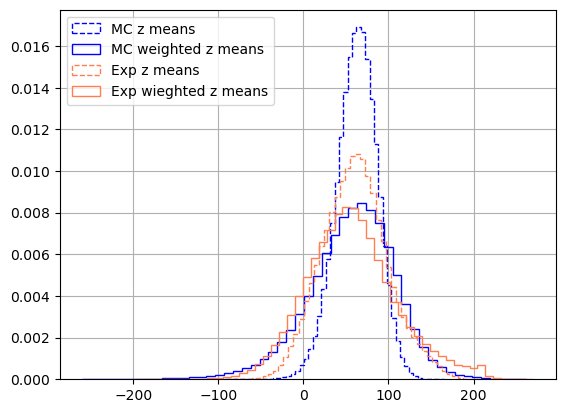

In [75]:
kwargs = dict(histtype='step', density=True)
plt.hist(mc_z_mean[~labels], bins=50, **kwargs, label='MC z means', ls='--', color='b')
plt.hist(mc_z_weight_q[~labels], bins=50, **kwargs, label='MC weighted z means', ls='-', color='b')
# plt.hist(mc_z_mean[labels], bins=50, **kwargs, label='MC z means', ls='--', color='b')
# plt.hist(mc_z_weight_q[labels], bins=50, **kwargs, label='MC weighted z means', ls='-', color='b')
plt.hist(exp_z_mean, bins=50, **kwargs, label='Exp z means', ls='--', color='coral')
plt.hist(exp_z_weight_q, bins=50, **kwargs, label='Exp wieghted z means', color='coral')
plt.grid()
plt.legend()
plt.show()

In [64]:
mc_z_mean.mean() - exp_z_mean.mean()

np.float32(27.897388)

In [53]:
labels

array([ True, False,  True, ..., False,  True, False], shape=(1000000,))

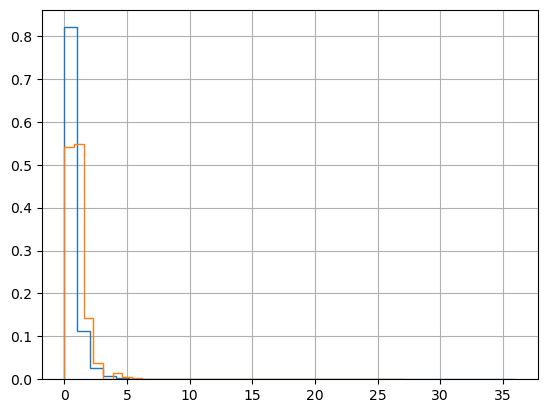

In [18]:
kwargs = dict(histtype='step', density=True)
plt.hist(mc_qgt10_num[~labels], bins=35, **kwargs)
plt.hist(exp_qgt10_num, bins=35, **kwargs)
plt.grid()

# TODO: load reco and compare

# UMAP

In [80]:
# UMAP visualization of source vs target feature distributions
print("=== UMAP Analysis of Feature Space ===")

# Install umap if not available (uncomment if needed)
# !pip install umap-learn

import umap
from matplotlib.patches import Patch

# Prepare data for UMAP visualization
print("Preparing data for UMAP visualization...")

# Use a subset for visualization (UMAP can be slow on large datasets)
n_viz_samples = 10000  # Adjust based on computational resources
n_source_viz = min(n_viz_samples // 2, len(source_features_mu))
n_target_viz = min(n_viz_samples // 2, len(target_features))

# Sample source features (MC muons)
source_viz_indices = np.random.choice(len(source_features_mu), n_source_viz, replace=False)
source_viz_features = source_features_mu[source_viz_indices].cpu().numpy()

# Sample target features (Experimental data)  
target_viz_indices = np.random.choice(len(target_features), n_target_viz, replace=False)
target_viz_features = target_features[target_viz_indices].cpu().numpy()

# Combine for UMAP fitting
all_viz_features = np.concatenate([source_viz_features, target_viz_features], axis=0)
domain_viz_labels = np.concatenate([
    np.zeros(n_source_viz),  # 0 = source (MC)
    np.ones(n_target_viz)    # 1 = target (Exp)
], axis=0)

print(f"UMAP visualization data:")
print(f"- Source (MC) samples: {n_source_viz:,}")
print(f"- Target (Exp) samples: {n_target_viz:,}")
print(f"- Total samples: {len(all_viz_features):,}")
print(f"- Feature dimension: {all_viz_features.shape[1]}")

# Configure UMAP parameters
umap_params = {
    'n_neighbors': 15,      # Local neighborhood size
    'min_dist': 0.1,        # Minimum distance between points
    'n_components': 2,      # 2D embedding
    'metric': 'euclidean',  # Distance metric
    #'random_state': 42      # Reproducibility
}

print(f"\nUMAP parameters: {umap_params}")
print("Fitting UMAP (this may take a moment)...")

# Fit UMAP
reducer = umap.UMAP(**umap_params)
embedding = reducer.fit_transform(all_viz_features)

print("UMAP fitting completed!")

# Split embedding back to source and target
source_embedding = embedding[:n_source_viz]
target_embedding = embedding[n_source_viz:]

print(f"Embedding shape: {embedding.shape}")
print(f"Source embedding: {source_embedding.shape}")
print(f"Target embedding: {target_embedding.shape}")

=== UMAP Analysis of Feature Space ===
Preparing data for UMAP visualization...
UMAP visualization data:
- Source (MC) samples: 5,000
- Target (Exp) samples: 5,000
- Total samples: 10,000
- Feature dimension: 64

UMAP parameters: {'n_neighbors': 15, 'min_dist': 0.1, 'n_components': 2, 'metric': 'euclidean'}
Fitting UMAP (this may take a moment)...
UMAP fitting completed!
Embedding shape: (10000, 2)
Source embedding: (5000, 2)
Target embedding: (5000, 2)


NameError: name 'dd_copy' is not defined

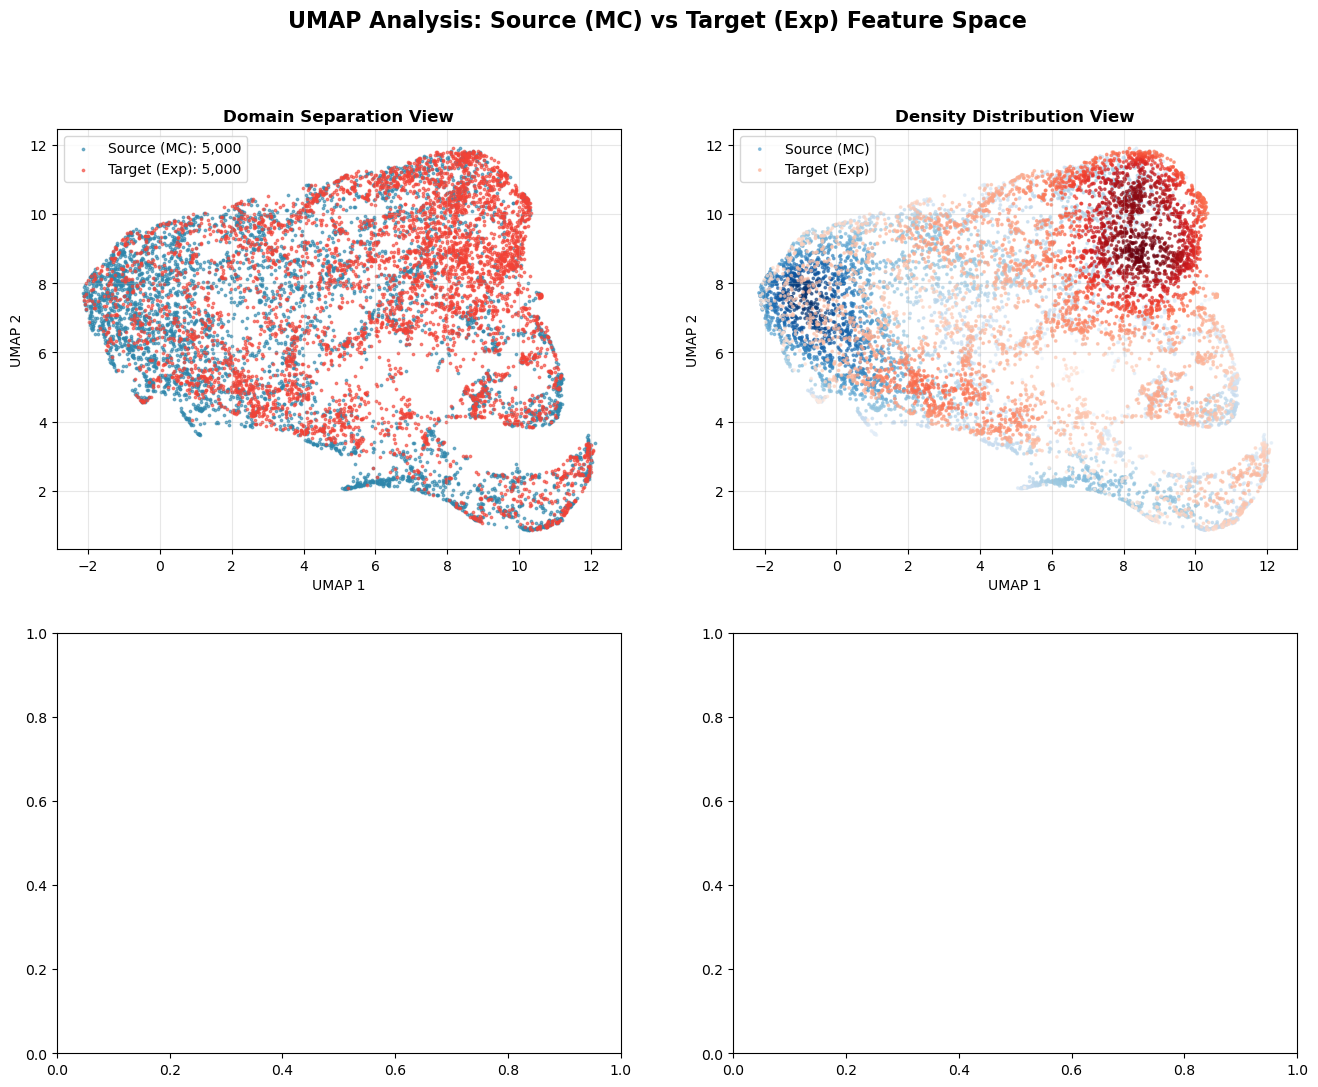

In [81]:
# Create comprehensive UMAP visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UMAP Analysis: Source (MC) vs Target (Exp) Feature Space', fontsize=16, fontweight='bold')

# Colors and styling
source_color = '#2E86AB'  # Blue for MC
target_color = '#F24236'  # Red for Exp
alpha = 0.6
point_size = 3

# Plot 1: Basic domain separation
ax1 = axes[0, 0]
scatter1 = ax1.scatter(source_embedding[:, 0], source_embedding[:, 1], 
                      c=source_color, alpha=alpha, s=point_size, label=f'Source (MC): {n_source_viz:,}')
scatter2 = ax1.scatter(target_embedding[:, 0], target_embedding[:, 1], 
                      c=target_color, alpha=alpha, s=point_size, label=f'Target (Exp): {n_target_viz:,}')
ax1.set_title('Domain Separation View', fontweight='bold')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Density-based visualization
ax2 = axes[0, 1]
# Create density plots
from scipy.stats import gaussian_kde

# Calculate point density for color mapping
source_xy = source_embedding.T
target_xy = target_embedding.T

# Source density
if len(source_xy[0]) > 1:
    source_density = gaussian_kde(source_xy)(source_xy)
    source_density = source_density / source_density.max()
else:
    source_density = np.ones(len(source_xy[0]))

# Target density  
if len(target_xy[0]) > 1:
    target_density = gaussian_kde(target_xy)(target_xy)
    target_density = target_density / target_density.max()
else:
    target_density = np.ones(len(target_xy[0]))

scatter3 = ax2.scatter(source_embedding[:, 0], source_embedding[:, 1], 
                      c=source_density, cmap='Blues', s=point_size, alpha=alpha, label='Source (MC)')
scatter4 = ax2.scatter(target_embedding[:, 0], target_embedding[:, 1], 
                      c=target_density, cmap='Reds', s=point_size, alpha=alpha, label='Target (Exp)')
ax2.set_title('Density Distribution View', fontweight='bold')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Domain discrimination predictions overlay
ax3 = axes[1, 0]
# Get domain predictions for visualization samples
viz_features_tensor = torch.tensor(all_viz_features, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    dd_copy.eval()
    viz_domain_logits = dd_copy(viz_features_tensor)
    viz_domain_probs = torch.sigmoid(viz_domain_logits.squeeze()).cpu().numpy()

# Color by domain discrimination confidence
scatter5 = ax3.scatter(embedding[:, 0], embedding[:, 1], 
                      c=viz_domain_probs, cmap='RdYlBu_r', s=point_size, 
                      alpha=alpha, vmin=0, vmax=1)
cbar = plt.colorbar(scatter5, ax=ax3)
cbar.set_label('Domain Discrimination\nProbability (0=MC, 1=Exp)', rotation=270, labelpad=20)
ax3.set_title('Domain Discriminator Predictions', fontweight='bold')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)

# Plot 4: Overlap analysis
ax4 = axes[1, 1]
# Create contour plots to show overlap
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

# Kernel density estimation for contours
if len(source_embedding) > 10:
    source_kde = gaussian_kde(source_embedding.T)
    target_kde = gaussian_kde(target_embedding.T)
    
    # Create grid for contour plots
    x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
    y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    source_density_grid = source_kde(positions).reshape(xx.shape)
    target_density_grid = target_kde(positions).reshape(xx.shape)
    
    # Plot contours
    source_contour = ax4.contour(xx, yy, source_density_grid, colors=[source_color], alpha=0.8, levels=5)
    target_contour = ax4.contour(xx, yy, target_density_grid, colors=[target_color], alpha=0.8, levels=5)
    
    # Add scatter points
    ax4.scatter(source_embedding[:, 0], source_embedding[:, 1], 
               c=source_color, alpha=0.3, s=point_size/2, label='Source (MC)')
    ax4.scatter(target_embedding[:, 0], target_embedding[:, 1], 
               c=target_color, alpha=0.3, s=point_size/2, label='Target (Exp)')
    
    # Create legend with patches
    source_patch = mpatches.Patch(color=source_color, label='Source (MC) Density')
    target_patch = mpatches.Patch(color=target_color, label='Target (Exp) Density')
    ax4.legend(handles=[source_patch, target_patch])
else:
    # Fallback if too few points
    ax4.scatter(source_embedding[:, 0], source_embedding[:, 1], 
               c=source_color, alpha=alpha, s=point_size, label='Source (MC)')
    ax4.scatter(target_embedding[:, 0], target_embedding[:, 1], 
               c=target_color, alpha=alpha, s=point_size, label='Target (Exp)')
    ax4.legend()

ax4.set_title('Density Overlap Analysis', fontweight='bold')
ax4.set_xlabel('UMAP 1')
ax4.set_ylabel('UMAP 2')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/umap_feature_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate overlap metrics
print("\n=== UMAP Feature Space Analysis ===")

# Calculate center distances
source_center = np.mean(source_embedding, axis=0)
target_center = np.mean(target_embedding, axis=0)
center_distance = np.linalg.norm(source_center - target_center)

# Calculate spread (average distance from center)
source_spread = np.mean(np.linalg.norm(source_embedding - source_center, axis=1))
target_spread = np.mean(np.linalg.norm(target_embedding - target_center, axis=1))
avg_spread = (source_spread + target_spread) / 2

# Overlap ratio
overlap_ratio = center_distance / avg_spread

print(f"Feature space metrics:")
print(f"- Source cluster center: ({source_center[0]:.2f}, {source_center[1]:.2f})")
print(f"- Target cluster center: ({target_center[0]:.2f}, {target_center[1]:.2f})")
print(f"- Center distance: {center_distance:.3f}")
print(f"- Average spread: {avg_spread:.3f}")
print(f"- Overlap ratio: {overlap_ratio:.3f} (lower = more overlap)")

# Interpretation
if overlap_ratio < 0.5:
    overlap_verdict = "✅ EXCELLENT overlap - domains are well mixed"
elif overlap_ratio < 1.0:
    overlap_verdict = "✅ GOOD overlap - domains partially mixed"  
elif overlap_ratio < 2.0:
    overlap_verdict = "⚠️ MODERATE overlap - some domain separation"
else:
    overlap_verdict = "❌ POOR overlap - domains clearly separated"

print(f"- Overlap assessment: {overlap_verdict}")

# Domain discrimination correlation
dd_accuracy_on_viz = accuracy_score(domain_viz_labels, (viz_domain_probs > 0.5).astype(int))
dd_auc_on_viz = roc_auc_score(domain_viz_labels, viz_domain_probs)
print(f"\nDomain discrimination on UMAP sample:")
print(f"- Accuracy: {dd_accuracy_on_viz:.4f}")
print(f"- AUC: {dd_auc_on_viz:.4f}")

print(f"\nUMAP analysis completed! Visualization saved to:")
print(f"{fig_dir}/umap_feature_analysis.png")